In [1]:
from sklearn.model_selection import train_test_split
import pandas as pd

# 깃허브에 준비된 데이터를 가져온다.
!git clone https://github.com/taehojo/data.git

# 집 값 데이터를 불러온다.
df = pd.read_csv("./data/house_train.csv")

# 데이터전처리
df = pd.get_dummies(df)
df = df.fillna(df.mean())

cols_train = ['OverallQual', 'GrLivArea', 'GarageArea', 'TotalBsmtSF']
X_train_pre = df[cols_train]
y = df['SalePrice'].values
X_train, X_test, y_train, y_test = train_test_split(X_train_pre, y, test_size=0.2)

Cloning into 'data'...
remote: Enumerating objects: 21, done.
remote: Counting objects: 100% (21/21), done.
remote: Compressing objects: 100% (18/18), done.
remote: Total 21 (delta 3), reused 20 (delta 2), pack-reused 0
Receiving objects: 100% (21/21), 460.95 KiB | 1.87 MiB/s, done.
Resolving deltas: 100% (3/3), done.


입력될 속성의 개수를 X_train.shape[1]로 지정해 자동으로 세도록 했다.

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

model = Sequential()
model.add(Dense(10, input_dim=X_train.shape[1], activation='relu'))
model.add(Dense(30, activation='relu'))
model.add(Dense(40, activation='relu'))
model.add(Dense(1))
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 10)                50        
                                                                 
 dense_1 (Dense)             (None, 30)                330       
                                                                 
 dense_2 (Dense)             (None, 40)                1240      
                                                                 
 dense_3 (Dense)             (None, 1)                 41        
                                                                 
Total params: 1661 (6.49 KB)
Trainable params: 1661 (6.49 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


선형 회귀이므로 평균 제곱 오차(mean_squared_error)를 적는다.

In [ ]:
model.compile(optimizer='adam', loss='mean_squared_error')

20번 이상 결과가 향상되지 않으면 자동으로 중단하게 한다.

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

early_stopping_callback = EarlyStopping(monitor='val_loss', patience=20)

modelpath = "./data/model/Ch15-house.hdf5"

checkpointer = ModelCheckpoint(filepath=modelpath, monitor='val_loss',
                               verbose=0, save_best_only=True)

history = model.fit(X_train, y_train, validation_split=0.25, epochs=2000,
                    batch_size=32, callbacks=[early_stopping_callback, checkpointer])

Epoch 1/2000
28/28 [==============================] - 2s 28ms/step - loss: 37884178432.0000 - val_loss: 38836207616.0000
Epoch 2/2000
18/28 [==================>...........] - ETA: 0s - loss: 36921556992.0000

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


28/28 [==============================] - 0s 8ms/step - loss: 37393158144.0000 - val_loss: 38141509632.0000
Epoch 3/2000
28/28 [==============================] - 0s 6ms/step - loss: 36372029440.0000 - val_loss: 36551024640.0000
Epoch 4/2000
28/28 [==============================] - 0s 6ms/step - loss: 33970593792.0000 - val_loss: 32966647808.0000
Epoch 5/2000
28/28 [==============================] - 0s 6ms/step - loss: 29136885760.0000 - val_loss: 26355191808.0000
Epoch 6/2000
28/28 [==============================] - 0s 6ms/step - loss: 21255075840.0000 - val_loss: 16811283456.0000
Epoch 7/2000
28/28 [==============================] - 0s 6ms/step - loss: 11770104832.0000 - val_loss: 7165030400.0000
Epoch 8/2000
28/28 [==============================] - 0s 4ms/step - loss: 4777483776.0000 - val_loss: 2341348864.0000
Epoch 9/2000
28/28 [==============================] - 0s 4ms/step - loss: 2699825920.0000 - val_loss: 1562408320.0000
Epoch 10/2000
28/28 [==============================] - 0s 

실습| 주택 가격 예측하기

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt
import seaborn as sns

import pandas as pd
import numpy as np

# 깃허브에 준비된 데이터를 가져온다.
!git clone https://github.com/taehojo/data.git

# 카테고리형 변수를 0과 1로 이루어진 변수로 바꾸어 준다.
df = pd.get_dummies(df)

# 결측치를 전체 칼럼의 평균으로 대체해 채워 준다.
df = df.fillna(df.mean())

# 데이터 사이의 상관관계를 저장한다.
df_corr = df.corr()

# 집 값과 관련이 큰 것부터 순서대로 저장한다.
df_corr_sort = df_corr.sort_values('SalePrice', ascending=False)

# 집 값을 제외한 나머지 열을 저장한다.
cols_train = ['OverallQual', 'GrLivArea', 'GarageCars', 'GarageArea', 'TotalBsmtSF']
X_train_pre = df[cols_train]

# 집 값을 저장한다.
y = df['SalePrice'].values

# 전체의 80%를 학습셋으로, 20%를 테스트셋으로 지정한다.
X_train, X_test, y_train, y_test = train_test_split(X_train_pre, y, test_size=0.2)

# 모델의 구조를 설정한다.
model = Sequential()
model.add(Dense(10, input_dim=X_train.shape[1], activation='relu'))
model.add(Dense(30, activation='relu'))
model.add(Dense(40, activation='relu'))
model.add(Dense(1))
model.summary()

# 모델을 실행한다.
model.compile(optimizer='adam', loss='mean_squared_error')

# 20번 이상 결과가 향상되지 않으면 자동으로 중단되게끔 한다.
early_stopping_callback = EarlyStopping(monitor='val_loss', patience=20)

# 모델의 이름을 정한다.
modelpath = "./data/model/Ch15-house.hdf5"

# 최적화 모델을 업데이트하고 저장한다.
checkpointer = ModelCheckpoint(filepath=modelpath, monitor='val_loss',
                               verbose=0, save_best_only=True)

# 실행 관련 설정을 하는 부분이다. 전체 20%를 검증셋으로 설정한다.
history = model.fit(X_train, y_train, validation_split=0.25, epochs=2000,
                    batch_size=32, callbacks=[early_stopping_callback, checkpointer])

fatal: destination path 'data' already exists and is not an empty directory.
Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_4 (Dense)             (None, 10)                60        
                                                                 
 dense_5 (Dense)             (None, 30)                330       
                                                                 
 dense_6 (Dense)             (None, 40)                1240      
                                                                 
 dense_7 (Dense)             (None, 1)                 41        
                                                                 
Total params: 1671 (6.53 KB)
Trainable params: 1671 (6.53 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________
Epoch 1/2000
28/28 [==============================] - 1s 10ms/step - loss: 40

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


28/28 [==============================] - 0s 5ms/step - loss: 39519010816.0000 - val_loss: 34914385920.0000
Epoch 4/2000
28/28 [==============================] - 0s 4ms/step - loss: 38318555136.0000 - val_loss: 33132142592.0000
Epoch 5/2000
28/28 [==============================] - 0s 4ms/step - loss: 35467513856.0000 - val_loss: 29175719936.0000
Epoch 6/2000
28/28 [==============================] - 0s 4ms/step - loss: 29749405696.0000 - val_loss: 22234920960.0000
Epoch 7/2000
28/28 [==============================] - 0s 5ms/step - loss: 20698583040.0000 - val_loss: 12786848768.0000
Epoch 8/2000
28/28 [==============================] - 0s 4ms/step - loss: 10610264064.0000 - val_loss: 4421867008.0000
Epoch 9/2000
28/28 [==============================] - 0s 4ms/step - loss: 3805380352.0000 - val_loss: 1528118016.0000
Epoch 10/2000
28/28 [==============================] - 0s 4ms/step - loss: 2237586944.0000 - val_loss: 1510760960.0000
Epoch 11/2000
28/28 [==============================] - 0s

In [ ]:
real_prices = []
pred_prices = []
X_num = []

n_iter = 0
Y_prediction = model.predict(X_test).flatten() # 2차원 배열에서 1차원 배열로 변경
for i in range(25):
    real = y_test[i]
    prediction = Y_prediction[i]
    print("실제가격: {:.2f}, 예상가격: {:.2f}".format(real, prediction))
    real_prices.append(real)
    pred_prices.append(prediction)
    n_iter = n_iter + 1
    X_num.append(n_iter)

10/10 [==============================] - 0s 2ms/step
실제가격: 179000.00, 예상가격: 197862.02
실제가격: 213490.00, 예상가격: 199966.03
실제가격: 167900.00, 예상가격: 203734.77
실제가격: 193000.00, 예상가격: 199330.94
실제가격: 217000.00, 예상가격: 216391.53
실제가격: 92000.00, 예상가격: 73805.11
실제가격: 116050.00, 예상가격: 121762.26
실제가격: 132000.00, 예상가격: 166098.02
실제가격: 214900.00, 예상가격: 196370.38
실제가격: 235000.00, 예상가격: 319905.12
실제가격: 92900.00, 예상가격: 91162.34
실제가격: 135500.00, 예상가격: 143128.59
실제가격: 315000.00, 예상가격: 290811.25
실제가격: 181000.00, 예상가격: 198353.89
실제가격: 282922.00, 예상가격: 228727.20
실제가격: 180000.00, 예상가격: 217766.22
실제가격: 230000.00, 예상가격: 222552.58
실제가격: 257000.00, 예상가격: 261486.84
실제가격: 207500.00, 예상가격: 203187.31
실제가격: 173000.00, 예상가격: 182926.84
실제가격: 318000.00, 예상가격: 258916.94
실제가격: 145500.00, 예상가격: 146226.05
실제가격: 189000.00, 예상가격: 196225.14
실제가격: 194500.00, 예상가격: 191226.31
실제가격: 135000.00, 예상가격: 181119.78


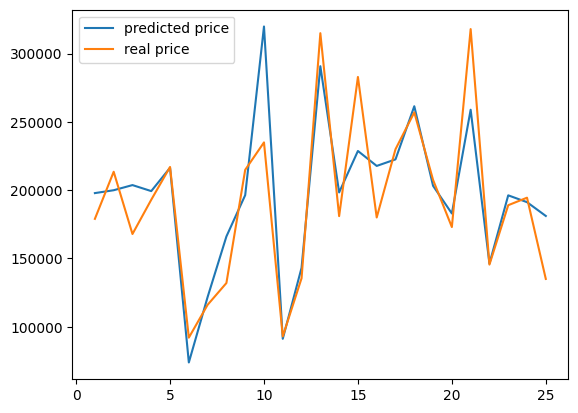

In [ ]:
plt.plot(X_num, pred_prices, label='predicted price')
plt.plot(X_num, real_prices, label='real price')
plt.legend()
plt.show()